# CODE TO WEBSCRAPE FROM KICKSTARTER.com
1) first of all download all the necessary libraries (there are some duplicates but I am too lazy to remove them )

In [2]:
import json
import re
import html
import ast
import random 
import numpy as np
import matplotlib.pyplot as plt
import os 
from pathlib import Path
from bs4 import BeautifulSoup
import pandas as pd 
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait 
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import undetected_chromedriver as uc

# INSTRUCTIONS: 
- scrapde_urls.txt keeps track of every URL scraped (doesn't matter if valid description or not), so that we don't include the same one twice 
- kickstarter_scraped_all.csv accumulates only the valid projects


# Kickstarter dataset 


We used 'https://webrobots.io/kickstarter-datasets/', there you can find and download the zip file that contains the screenshot of the webiste for the month. In that zip there are a bunch of CSVs that need to be put together (they are different file because putting them all in one single CSV would be too large). So we first get those and put them all together and from that dataset we only want the links (these are the links to the official kickstarter page for each project), then we use these links in a loop that extracts the descriptions by webscraping and also gets the % of how much each project got funded. 


In [2]:
import pandas as pd
import glob


folder_path = "Kickstarter_2026-03-12T03_20_26_556Z"

files = glob.glob(f"{folder_path}/*.csv")

print("Number of files found:", len(files))

dfs = []

for file in files:
    print("Loading:", file)
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Final shape:", df.shape)

Number of files found: 85
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter014.csv
Lo

Here we plotted the distribution of the project goals, and decided that we would keep only projects with at least 5000 USD in project goal. This is done to restrict the sample to only real campaigns, and avoiding fake / not relevant campaigns on the website, due to the large amount of data we could sample from. 

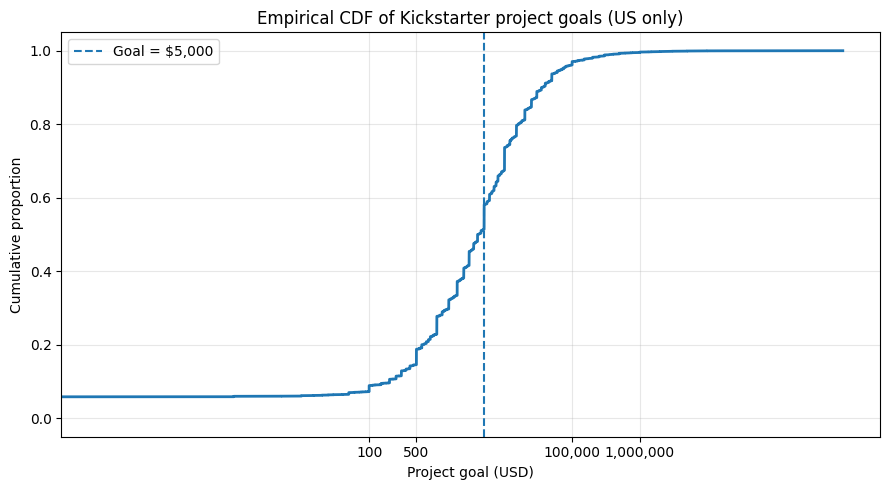

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

goals = df['goal'].dropna()

x = np.sort(goals.values)
y = np.arange(1, len(x) + 1) / len(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, linewidth=2)
ax.axvline(5000, linestyle='--', linewidth=1.5, label='Goal = $5,000')

ax.set_xscale('log')

ticks = [100, 500, 100000, 1000000]
ticks = [t for t in ticks if x.min() <= t <= x.max()]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{t:,.0f}' for t in ticks])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_xlabel('Project goal (USD)')
ax.set_ylabel('Cumulative proportion')
ax.set_title('Empirical CDF of Kickstarter project goals (US only)')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
df

,backers_count,blurb,category,converted_pledged_amount,country,country_displayable_name,created_at,creator,currency,currency_symbol,...,spotlight,staff_pick,state,state_changed_at,static_usd_rate,urls,usd_exchange_rate,usd_pledged,usd_type,video
0,2,Built for the Pump. Tailored to Fit. esc4pe Gy...,"{""id"":269,""name"":""Ready-to-wear"",""analytics_na...",146.0,DE,Germany,1751226756,"{""id"":865203874,""name"":""esc4pe gymwear"",""slug""...",EUR,€,...,False,False,failed,1757527203,1.166456,"{""web"":{""project"":""https://www.kickstarter.com...",1.170848,145.806942,domestic,"{""id"":1377608,""status"":""successful"",""hls"":""htt..."
1,1,Tech Meets Totem: High-Tech &Advanced-Stain-Re...,"{""id"":269,""name"":""Ready-to-wear"",""analytics_na...",115.0,CA,Canada,1752282286,"{""id"":721218801,""name"":""Jessica Lyu"",""is_regis...",CAD,$,...,False,False,failed,1757049287,0.725141,"{""web"":{""project"":""https://www.kickstarter.com...",0.724257,116.022488,domestic,"{""id"":1375141,""status"":""successful"",""hls"":""htt..."
2,11,Sharing joy and cuteness via images of baby go...,"{""id"":353,""name"":""Stationery"",""analytics_name""...",482.0,US,the United States,1674844300,"{""id"":1717046955,""name"":""Teresa Oliver"",""slug""...",USD,$,...,True,False,successful,1678331521,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,482.000000,domestic,NaN
3,35,Intel Ultra CPU | Integrated AI-Enhanced GPU &...,"{""id"":52,""name"":""Hardware"",""analytics_name"":""H...",48555.0,US,the United States,1721269019,"{""id"":914589792,""name"":""Giada Tech"",""slug"":""gi...",USD,$,...,True,False,successful,1727359213,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,48555.000000,domestic,"{""id"":1309417,""status"":""successful"",""hls"":""htt..."
4,227,Compact Design. Multi-function. Simplify Life....,"{""id"":28,""name"":""Product Design"",""analytics_na...",17957.0,HK,Hong Kong,1723352304,"{""id"":240625457,""name"":""EckDesign"",""slug"":""eck...",HKD,$,...,True,False,successful,1727359082,0.128287,"{""web"":{""project"":""https://www.kickstarter.com...",0.128451,17934.284200,domestic,"{""id"":1307319,""status"":""successful"",""hls"":""htt..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268534,8,We are healing the world one immersive experie...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",761.0,US,the United States,1750357647,"{""id"":755375393,""name"":""Tricia Keightley"",""slu...",USD,$,...,False,False,failed,1753562000,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,761.000000,domestic,"{""id"":1369696,""status"":""successful"",""hls"":""htt..."
268535,7,A unique project that revolutionizes working o...,"{""id"":332,""name"":""Apps"",""analytics_name"":""Apps...",1443.0,US,the United States,1750679728,"{""id"":1072886381,""name"":""Taco Fleur"",""slug"":""k...",USD,$,...,False,False,failed,1752693465,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,1443.000000,domestic,"{""id"":1369574,""status"":""successful"",""hls"":""htt..."
268536,106,The Wall 2061 is a city-wide live-action rolep...,"{""id"":271,""name"":""Live Games"",""analytics_name""...",6788.0,DE,Germany,1506518699,"{""id"":257137944,""name"":""Gamestorm Berlin"",""slu...",EUR,€,...,True,True,successful,1519376417,1.225988,"{""web"":{""project"":""https://www.kickstarter.com...",1.230158,6764.999025,domestic,"{""id"":852289,""status"":""successful"",""hls"":null,..."
268537,15,"A son needs money from his rich, estranged fat...","{""id"":31,""name"":""Narrative Film"",""analytics_na...",3600.0,US,the United States,1448311257,"{""id"":870950346,""name"":""Anthony Riso"",""is_regi...",USD,$,...,True,False,successful,1450976401,1.000000,"{""web"":{""project"":""https://www.kickstarter.com...",1.000000,3600.000000,domestic,"{""id"":616283,""status"":""successful"",""hls"":null,..."


Here we look at the possible categories in the dataset, we extracted them since they are in a JSON format in each row

In [4]:

category_names = []

for item in df['category']:
    parsed = json.loads(item)
    name = parsed['name']
    if name not in category_names:
        category_names.append(name)

print(category_names, len(category_names))


parent_names = set()

for item in df['category']:
    parsed = ast.literal_eval(item)
    if 'parent_name' in parsed:
        parent_names.add(parsed['parent_name'])

print(parent_names)
print(len(parent_names))

category_counts = {}

for item in df['category']:
    parsed = ast.literal_eval(item)
    if 'parent_name' in parsed:
        parent = parsed['parent_name']
        if parent in category_counts:
            category_counts[parent] += 1
        else:
            category_counts[parent] = 1

print(category_counts)



['Ready-to-wear', 'Stationery', 'Hardware', 'Product Design', 'Web', 'Indie Rock', 'Puzzles', 'Anthologies', 'Art Books', 'Apparel', 'Television', 'Wearables', 'Accessories', 'Mobile Games', 'Comedy', 'Science Fiction', 'DIY', 'DIY Electronics', 'Jewelry', 'Academic', 'Textiles', 'Horror', 'Comic Books', 'Drama', 'Hip-Hop', 'Video Games', 'Tabletop Games', 'Playing Cards', 'Pottery', 'Pet Fashion', 'Thrillers', 'Shorts', 'Graphic Novels', 'Fabrication Tools', 'Illustration', 'Performance Art', 'People', 'Faith', 'Classical Music', 'Gadgets', 'Sound', 'Experimental', 'Zines', 'Apps', 'Mixed Media', 'Woodworking', '3D Printing', 'Country & Folk', 'Robots', 'Technology', 'Metal', 'Animation', 'Immersive', 'Family', 'Performances', 'Webseries', 'Fiction', 'Fantasy', 'Kids', 'Software', 'Documentary', 'Live Games', "Children's Books", 'Architecture', 'Young Adult', 'Toys', 'Photobooks', 'Small Batch', 'Bacon', 'Fine Art', 'Music', 'Literary Journals', 'Nonfiction', 'Photography', 'Punk', 'D

Since we limited our analysis to the top 5 most common categories, we selected only those, which are the categories that have at least 22000 projects in the dataset

In [5]:
final_categories = {}
for item in category_counts:
    if category_counts[item] > 22000:
        final_categories[item] = category_counts[item]

final_categories

{'Technology': 24149,
 'Music': 30156,
 'Games': 24781,
 'Publishing': 29262,
 'Film & Video': 34861}

# CLEANING THE DATASET 

Here we just do some data cleaning on the dataset, and introduce some of the filters we already mentioned

In [6]:
copy = df[df['country'] == 'US']
copy = copy[copy['usd_pledged'] > 0]
copy['pct_goal_reached'] = (copy['usd_pledged'] / copy['goal']) * 100
copy = copy[copy['pct_goal_reached'] > 1]
copy = copy[copy['usd_pledged'] == copy['converted_pledged_amount']]
copy = copy[copy['state'] != 'canceled']

copy = copy[copy['goal'] > 5000]


def get_parent_name(item):
    parsed = ast.literal_eval(item)
    return parsed.get('parent_name', None)

copy['parent_name'] = copy['category'].apply(get_parent_name)
copy = copy[copy['parent_name'].isin(final_categories.keys())]

len(copy)

25325

here is an example of campaign description:

In [7]:
copy.iloc[4,1]

"Automatically Activated Audio/Visual Beacon for Fire Emergencies (attaches to pet's collar). Activated by ANY Fire Alarm."

We defined a function to extract the urls from the dataset

In [8]:
def extract_project_url(x):
    if pd.isna(x):
        return None
    try:
        d = json.loads(x)
        return d.get("web", {}).get("project")
    except:
        return None
    
copy["project_url"] = copy['urls'].apply(extract_project_url)

print(copy["project_url"].notna().sum())
print(copy["project_url"].dropna().head())

25325
27    https://www.kickstarter.com/projects/blackball...
36    https://www.kickstarter.com/projects/claw/elec...
42    https://www.kickstarter.com/projects/boltind/b...
56    https://www.kickstarter.com/projects/181882321...
63    https://www.kickstarter.com/projects/selfascop...
Name: project_url, dtype: object


We keep track of the already scraped urls in the 'scraped_urls.txt' file to be sure that at each iteration of the webscraping loop, we only sample urls that are not in the dataset already. 

In [9]:
df_valid = copy[copy['project_url'].notna()]
# If a tracking file exists, load already-scraped URLs
if os.path.exists('scraped_urls.txt'):
    with open('scraped_urls.txt', 'r') as f:
        scraped_urls = set(f.read().splitlines())
else:
    scraped_urls = set()


# Filter out already-scraped URLs
df_remaining = df_valid[~df_valid["project_url"].isin(scraped_urls)]
print(f"Already scraped: {len(scraped_urls)}")
print(f"Remaining: {len(df_remaining)}")
print(df_remaining['parent_name'].value_counts())

Already scraped: 4778
Remaining: 18479
parent_name
Music           5895
Film & Video    5544
Publishing      3086
Technology      2933
Games           1021
Name: count, dtype: int64


here we define the sampling from the url list to be webscraped

In [ ]:
n_categories = df_remaining['parent_name'].nunique()
batch_size = 500 #can be different depending how many campaigns you want to webscrape each time you run the next loop

n_per_category = batch_size // n_categories

sample_balanced = (
    df_remaining
    .groupby('parent_name')
    .sample(n=n_per_category)
)

batch_urls = sample_balanced["project_url"].tolist()
print(f"Categories: {n_categories}, per category: {n_per_category}, total: {len(batch_urls)}")
print(sample_balanced['parent_name'].value_counts())
print(len(batch_urls), 'projects :', batch_urls)

Categories: 5, per category: 5, total: 25
parent_name
Film & Video    5
Games           5
Music           5
Publishing      5
Technology      5
Name: count, dtype: int64
25 projects : ['https://www.kickstarter.com/projects/kennedyhillfilm/kennedy-hill-a-david-lynch-ma-in-film-master-thesi', 'https://www.kickstarter.com/projects/starquakeseries/quest-of-the-muscle-nerd-finishing-funds', 'https://www.kickstarter.com/projects/1352934276/dizzler-in-maskheraid', 'https://www.kickstarter.com/projects/200429773/the-wrong-todd-feature-film-about-love-and-paralle', 'https://www.kickstarter.com/projects/1686158489/dino-might-a-reality-show-with-a-big-bang', 'https://www.kickstarter.com/projects/burningwheel/inheritance-0', 'https://www.kickstarter.com/projects/tieramay/ritual-tarot-expanded-edition', 'https://www.kickstarter.com/projects/pulphummock/gotfn-trilogy', 'https://www.kickstarter.com/projects/codexsilenda/codex-silenda-remastered', 'https://www.kickstarter.com/projects/1498366004/b3-be

Here we define the function that actually loads the webpage and scrapes the site to download the information

In [12]:

def scrape_kickstarter_description(url: str) -> dict:
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu") 
    options.add_argument("--window-size=1920,1080")       
    options.add_argument("--disable-extensions")          
    options.add_argument("--disable-software-rasterizer")  
    options.add_argument("--remote-debugging-port=0")     
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )

    driver = webdriver.Chrome(
        service=Service(ChromeDriverManager().install()),
        options=options
    )

    try:
        driver.get(url)

        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.CLASS_NAME, "rte__content"))
        )

        time.sleep(2)
        html_source = driver.page_source
        soup = BeautifulSoup(html_source, "html.parser")

        
        description_div = soup.find("div", class_="rte__content")
        description = (
            description_div.get_text(separator=" ", strip=True)
            if description_div else None
        )

        
        title = soup.find("h1", class_="project-name")
        if not title:
            title = soup.find("h2")
        title = title.get_text(strip=True) if title else None

        funding = {
            "pledged": None,
            "usd_pledged": None,
            "converted_pledged_amount": None,
            "goal": None,
            "currency": None
        }

        for script in soup.find_all("script"):
            script_text = script.string or script.get_text()
            if "window.current_project" not in script_text:
                continue

            match = re.search(
                r'window\.current_project\s*=\s*"(.+?)";',
                script_text,
                re.DOTALL
            )
            if not match:
                continue

            raw = match.group(1)

            raw = html.unescape(raw)
            try:
                raw = raw.encode("utf-8").decode("unicode_escape")
            except Exception: 
                pass

            try:
                project_data = json.loads(raw)
                funding = {
                    "pledged": project_data.get("pledged"),
                    "usd_pledged": project_data.get("usd_pledged"),
                    "converted_pledged_amount": project_data.get("converted_pledged_amount"),
                    "goal": project_data.get("goal"),
                    "currency": project_data.get("currency")
                }
                break
            except json.JSONDecodeError:
                pass

    finally:
        driver.quit()

    return {
        "url": url,
        "title": title,
        "description": description,
        **funding
    }





Here we introduced a filter to only keep descriptions of minimum length = 800, this is measured in characters length so not words. we did this to only include campaigns that have a meaningful amount of text, rather than fake campaigns that could potentially have only a couple lines of text and a video. 

In [ ]:
MIN_DESCRIPTION_LENGTH = 800
output_file = 'raw_kickstarter.csv'
rows = []

for i, url in enumerate(batch_urls, start=1):
    print(f"Scraping {i}/{len(batch_urls)}: {url}")
    
    try:
        row = scrape_kickstarter_description(url)
    except Exception as e:
        print(f"  ✗ Error scraping {url}: {e}")
        continue

    desc = row.get("description")
    if desc and len(desc) >= MIN_DESCRIPTION_LENGTH:
        rows.append(row)
        scraped_urls.add(url)
        print(f"  ✓ Saved (length: {len(desc)})")
        time.sleep(random.uniform(4, 9))
    else:
        print(f"  ⚠ Skipped (description too short or missing)")

    if i % 10 == 0:
        if rows:
            pd.DataFrame(rows).to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)
            rows = []  # clear rows after saving to avoid duplicates
        with open('scraped_urls.txt', 'w') as f:
            f.write('\n'.join(scraped_urls))
        print(f"  💾 Progress saved at {i}/{len(batch_urls)}")

    

if rows:
    pd.DataFrame(rows).to_csv(output_file, mode='a', header=not os.path.exists(output_file), index=False)

with open('scraped_urls.txt', 'w') as f:
    f.write('\n'.join(scraped_urls))

print(f"\nBatch complete.") 
print(f"Total URLs scraped so far: {len(scraped_urls)}")

Scraping 1/25: https://www.kickstarter.com/projects/kennedyhillfilm/kennedy-hill-a-david-lynch-ma-in-film-master-thesi
  ✓ Saved (length: 4706)
Scraping 2/25: https://www.kickstarter.com/projects/starquakeseries/quest-of-the-muscle-nerd-finishing-funds
  ✗ Error scraping https://www.kickstarter.com/projects/starquakeseries/quest-of-the-muscle-nerd-finishing-funds: Message: 
Stacktrace:
	chromedriver!GetHandleVerifier [0x113ad03+10893]
	chromedriver!GetHandleVerifier [0x113ae34+109c4]
	chromedriver!(No symbol) [0xf51ea0]
	chromedriver!(No symbol) [0xf9b26a]
	chromedriver!(No symbol) [0xf9b50b]
	chromedriver!(No symbol) [0xfdd022]
	chromedriver!(No symbol) [0xfbd7c4]
	chromedriver!(No symbol) [0xfda814]
	chromedriver!(No symbol) [0xfbd516]
	chromedriver!(No symbol) [0xf908c9]
	chromedriver!(No symbol) [0xf91684]
	chromedriver!GetHandleVerifier [0x13d31c4+2a8d54]
	chromedriver!GetHandleVerifier [0x13ce7cd+2a435d]
	chromedriver!GetHandleVerifier [0x13eea85+2c4615]
	chromedriver!GetHandleVe

This is a final loop to actually add some information to each row such as the actual category of the campaign, the date on which it was launched, the presence or not of a video on the webpage, and the campaign's deadline 

In [20]:
import glob
folder_path = "Kickstarter_2026-03-12T03_20_26_556Z"

files = glob.glob(f"{folder_path}/*.csv")

print("Number of files found:", len(files))

dfs = []

for file in files:
    print("Loading:", file)
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)


launched = {}
url_to_category = {}
deadline = {}
video = {}
for _, row in df.iterrows():
    parsed = ast.literal_eval(row['category'])
    parent_name = parsed.get('parent_name') or parsed.get('name')
    url_parsed = ast.literal_eval(row['urls'])
    project_url = url_parsed['web']['project']
    url_to_category[project_url] = parent_name
    launched[project_url] = row['launched_at']
    deadline[project_url] = row['deadline']
    video[project_url] = row['video']

campaigns['category'] = campaigns['url'].map(url_to_category)
campaigns['launched_at'] = campaigns['url'].map(launched)
campaigns['deadline'] = campaigns['url'].map(deadline)
campaigns['video'] = campaigns['url'].map(video)
 
print(f"Matched: {campaigns['category'].notna().sum()} / {len(campaigns)}")
print(campaigns['category'].value_counts())

Number of files found: 85
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter014.csv
Lo